# **Aprendizado de Máquina**<BR> **Aula 03** - Variáveis categóricas, métricas e validação

# **Exercício 1**: regressão linear com variáveis categóricas

## **1)** Importação de bibliotecas e classes

In [1]:
import pandas as pd                   # Leitura de dados e operações em DataFrames
from matplotlib import pyplot as plt  # Geração de gráficos
import numpy as np

from sklearn.linear_model import LinearRegression   # Regressão linear

## **2)** Leitura de dados e exploração inicial

In [21]:
# Antes de executar essa célula é preciso
# 1) "Montar" o disco
# 2) Ajustar o caminho do arquivo

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/A02EX1_carros.csv')
df.head()
#display(df)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,USA,ford torino


### **2.1)** Características gerais

In [3]:
# Dimensões do DataFrame
df.shape


(392, 9)

In [4]:
# Nomes das colunas
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [5]:
# Tipos de dados das variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 27.7+ KB


In [6]:
# Resumo estatístico
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [7]:
# Contagem das origens
df['origin'].value_counts()

,count
origin,
USA,245
Asia,79
Europe,68


### **2.2)** Gráficos

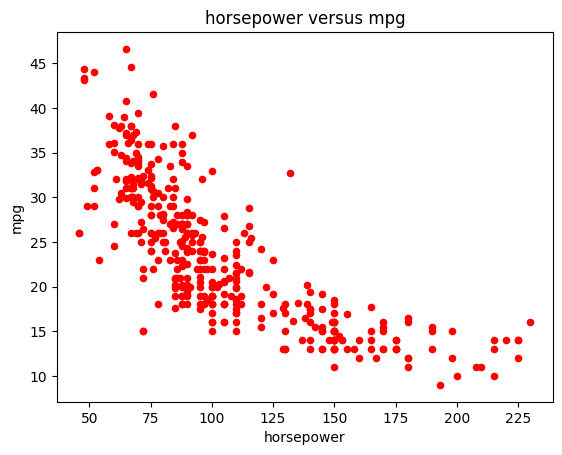

In [8]:
# Diagrama de dispersão entre y e x1
df.plot.scatter(x = 'horsepower',y = 'mpg',c = 'red')
plt.title("horsepower versus mpg")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.show()

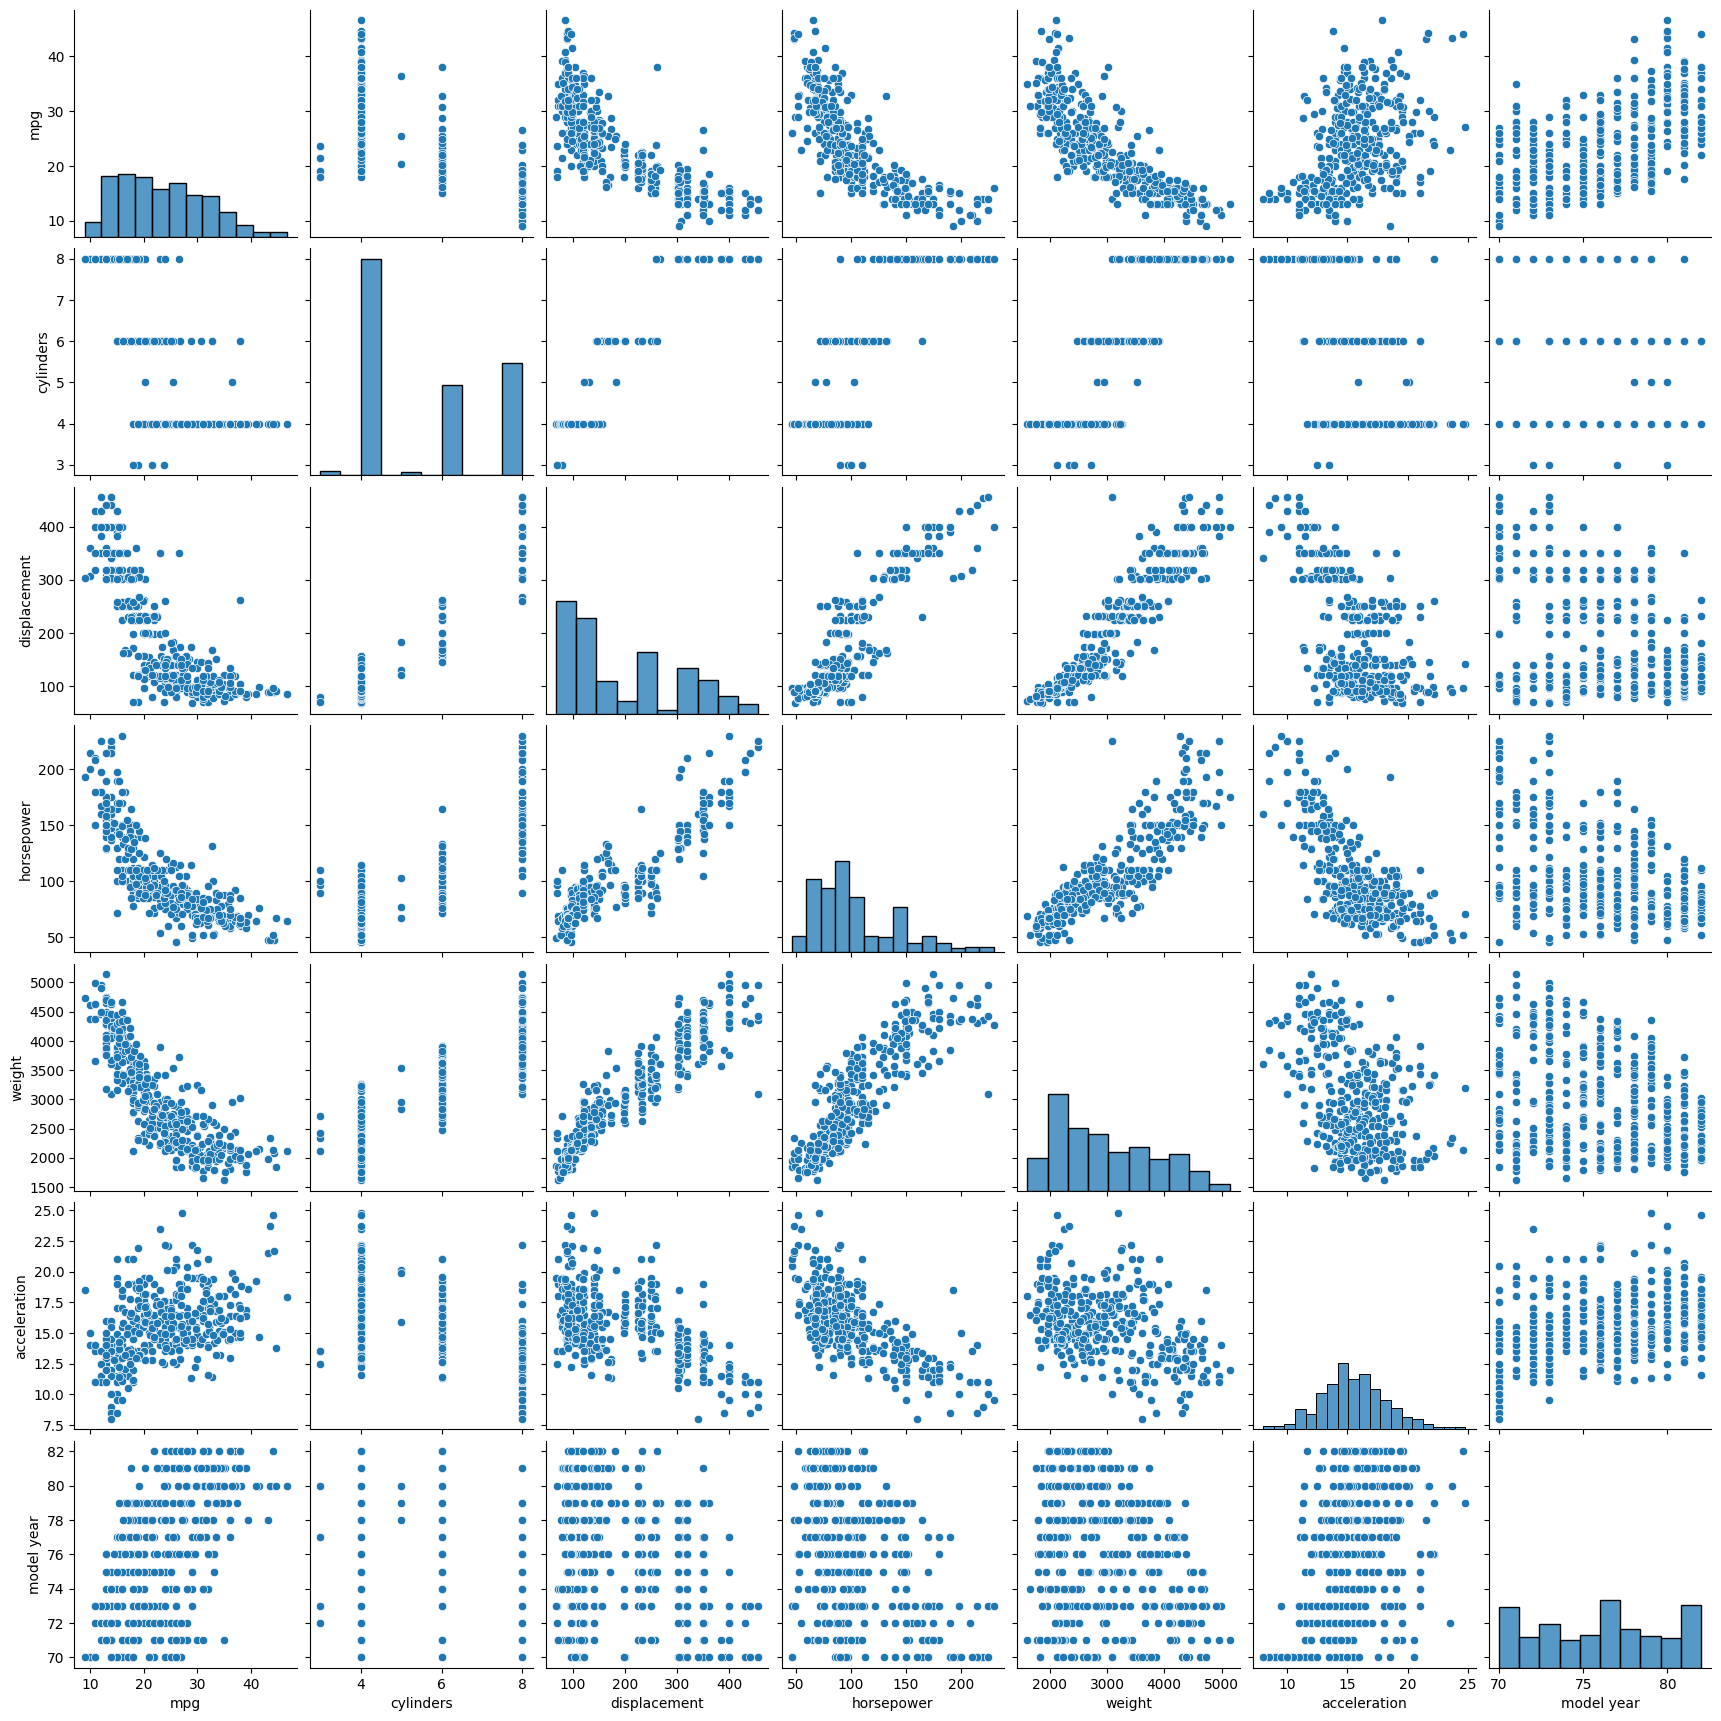

In [9]:
# Visualização "melhorada" dos diagramas de dispersão: biblioteca Seaborn!
# Importaçao da biblioteca e geração da matriz de diagramas de dispersão

import seaborn as sns
sns.pairplot(df)
plt.show()

### **2.3)** Correlações

In [10]:
# Análise das correlações lineares
# Critério: |r| entre 0 e 0,4: fraca
#           |r| acima de 0,4 e abaixo de 0,7: moderada
#           |r| maior ou igual a 0,7: forte
df.corr(numeric_only = True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


## **3)** Pré-processamanto e Seleção de variáveis

In [22]:
# Codificação one hot das origens dos automoveis
df = pd.get_dummies(df, columns = ['origin'], dtype = int, drop_first = True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,origin_Europe,origin_USA
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu,0,1
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320,0,1
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite,0,1
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst,0,1
4,17.0,8,302.0,140,3449,10.5,70,ford torino,0,1


In [24]:
y = df['mpg']  # Variável dependente (mpg) comumo milhas por galão
X = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_Europe', 'origin_USA']]
X = df.drop(columns= ['mpg', 'car name']) # Variaveis independentes


## **4)** Treinamento do modelo (regressão linear múltipla)

In [28]:
# Forma do modelo: y^ = f(x1,x2) = theta_0 + theta_1*x1 + theta_2*x2

reg = LinearRegression() # Cria objeto de modelo liniar
reg.fit(X,y)             # Treina o modelo usando todos os dados


LinearRegression()

## **5)** Exibição dos coeficientes do modelo e da qualidade do ajuste

In [30]:
# Coeficientes
print("Intercepto = ",reg.intercept_)
print("Coeficientes angulares = ",reg.coef_)

Intercepto =  -15.101373838812638
Coeficientes angulares =  [-0.48970942  0.02397864 -0.01818346 -0.00671038  0.07910304  0.77702694
 -0.22322587 -2.85322823]


In [62]:
# Função para o cálculo do coeficiente de determinação da regressão
# linear simples (R^2) ou múltipla (R^2 ajustado):

def R2_R2ajust(regressor,X,y):
  R2 = regressor.score(X,y)  # R^2
  n = len(y)      # Quantidade de dados de treino
  m = X.shape[1]  # Quantidade de variáveis independentes do modelo
  if m == 1:
    return R2   # Regressão simples: retorna R^2
  else:
    return 1-((n-1)/(n-m-1))*(1-R2)  # Regressão múltipla: R^2 ajustado

In [44]:
# Qualidade do ajuste
print('R^2 = ', R2_R2ajust(reg,X,y))

R^2 =  0.8205273961763957


## **6)** Previsão pontual

In [48]:
# Dados de previsão: x1 = 2, x2 = 50
# Cria dicionário de preovisão 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_Europe', 'origin_USA'
X_prev = {'cylinders': [6], 'displacement': [250], 'horsepower': [140], 'weight': [2850], 'acceleration': [10], 'model year': [90], 'origin_Europe': [0], 'origin_USA': [1]}

# Converte o dicionário em dataFrame
X_prev = pd.DataFrame(X_prev)

# Exibe o dataFrame
display(X_prev)

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_Europe,origin_USA
0,6,250,140,2850,10,90,0,1


In [49]:
# Previsão = y^(2,50)
y_prev = reg.predict(X_prev)
print('y_prev = ', round(y_prev[0], 3))

y_prev =  34.155


---
**Fim do Exercício 1 da Aula 03**

# **Exercício 2**. Validação do modelo do Exercício 1 (avaliação da capacidade de generalização)

## **1)** Validação cruzada *hold-out*

In [55]:
# Separação dos dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Parâmetros da função 'train_test_split':
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# train_size/test_size = percentual de dados de treino/teste. Padrão: 75% (treino) e 25% (teste)

# Divide os dados: 80% para treino ('train_size'), 20% para teste
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução do método de divisão
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8)

print("Dimensões dos dados de treino:",X_treino.shape)
print("Dimensões dos dados de teste:",X_teste.shape)

Dimensões dos dados de treino: (313, 8)
Dimensões dos dados de teste: (79, 8)


In [56]:
# Treinamento do modelo (apenas) com os dados de treino (80% do total)
reg_treino = LinearRegression()
reg_treino.fit(X_treino,y_treino)

LinearRegression()

In [63]:
# Qualidade do ajuste
print("Coeficiente de determinação AJUSTADO =",R2_R2ajust(reg_treino,X_treino,y_treino))

Coeficiente de determinação AJUSTADO = 0.8203500100535694


In [65]:
# Erros de previsão
# RMSE e MAPE do modelo para os dados de teste

# Cálculo das previsões
y_prev_teste = reg_treino.predict(X_teste)

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

# Principais parâmetros das funções 'root_mean_squared_error' e
# 'mean_absolute_percentage_error':
# y_true = valores reais da variável dependente (y)
# y_pred = valores previstos pelo modelo para a variável dependente

RMSE = root_mean_squared_error(y_true = y_teste,y_pred = y_prev_teste)
MAPE = mean_absolute_percentage_error(y_true = y_teste,y_pred = y_prev_teste)
print("RMSE para os dados de teste =",RMSE)
print("MAPE para os dados de teste =",MAPE)

RMSE para os dados de teste = 3.11320490973601
MAPE para os dados de teste = 0.11088327197496085


## **2)** Validação cruzada *k-folds*

In [67]:
from sklearn.model_selection import cross_val_score

# Parâmetros da função 'cross_val_score':
# estimator = um estimador (neste caso, um objeto da classe 'LinearRegression')
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# scoring = texto indicativo da métrica de qualidade a ser calculada
# cv = número [inteiro] de partições (k); valor padrão: k = 5

# Executa a validação cruzada k-folds, com k = 10, avaliando a métrica RMSE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_root_mean_squared_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de RMSE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("RMSE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de RMSE obtidos: [3.09431766 2.96962267 3.34419237 2.94695467 2.26116813 2.64004982
 4.30759279 3.54509763 5.48761547 3.76094993]

RMSE médio = 3.4357561127739884
Coeficiente de variação (%) = 26.89001269694923


In [68]:
# Executa a validação cruzada, avaliando a métrica MAPE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_mean_absolute_percentage_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de MAPE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("MAPE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de MAPE obtidos: [0.17045472 0.14224007 0.15964088 0.14137701 0.08389788 0.11444544
 0.15044077 0.11243597 0.11555141 0.10091691]

MAPE médio = 0.12914010558375474
Coeficiente de variação (%) = 21.49561014113831


---
**Fim dos Exercícios 1 e 2 da Aula 03**